# Vaccination Prediction

# Project Overview

This project predicts whether a person will take the H1N1 or seasonal flu vaccine based on survey data from the 2009 flu pandemic. The dataset contains demographic, behavioral, medical, and opinion-based features that influence vaccination decisions.

We merge the features and labels, handle missing values, encode categorical variables, and scale numerical ones. After preprocessing, multiple machine-learning models are trained and compared (Logistic Regression, Random Forest, Gradient Boosting, KNN). The goal is to identify the model that best predicts vaccination behavior.

This prediction helps understand which factors drive or prevent vaccine adoption, supporting better public-health planning.

# Dataset Understanding

In [1]:
# imports libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline   # THIS IS THE ONE YOU MISSED

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix


In [2]:
# ------------------------------
# 2. Load the datasets
# ------------------------------
features = pd.read_csv("features.csv")
labels = pd.read_csv("labels.csv")

In [3]:
# Check the top rows
print("FEATURES DATA:")
display(features.head())

FEATURES DATA:


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [4]:
print("LABELS DATA:")
display(labels.head())

LABELS DATA:


,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0


In [5]:
# ------------------------------
# 3. Merge datasets
# ------------------------------
# Both files have respondent_id 
df = features.merge(labels, on="respondent_id", how="inner")

print("MERGED DATA:")
display(df.head())


MERGED DATA:


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


# Basic Checks

In [6]:
# ------------------------------
# 4. Basic Checks
# ------------------------------

# shape
print("Shape of merged data:", df.shape)

Shape of merged data: (26707, 38)


In [7]:
# info
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  c

In [8]:

# summary statistics
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


# EDA

In [9]:
# check missing values
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty 

In [10]:
# check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [11]:
# check target variable distribution
if 'h1n1_vaccine' in df.columns:
    print("\nTarget Distribution (h1n1_vaccine):")
    print(df['h1n1_vaccine'].value_counts())


Target Distribution (h1n1_vaccine):
h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64


In [12]:
# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
# If you have xgboost installed, you can use it:
# from xgboost import XGBClassifier


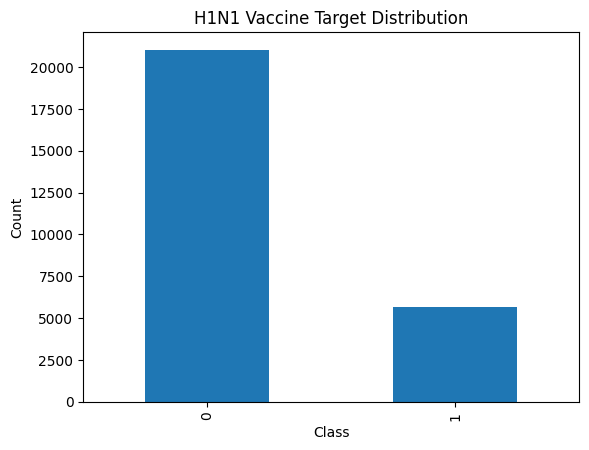

In [13]:
# Target distribution
fig, ax = plt.subplots()
df['h1n1_vaccine'].value_counts().plot(kind='bar', ax=ax)
ax.set_title("H1N1 Vaccine Target Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()


The bar chart shows the distribution of the H1N1 vaccine target variable. Class 0 (people who did not take the H1N1 vaccine) has a significantly higher count—over 21,000 individuals. Class 1 (people who did take the vaccine) is much smaller, with around 5,500 individuals. This creates a clear class imbalance, where the majority of respondents did not receive the H1N1 vaccine.

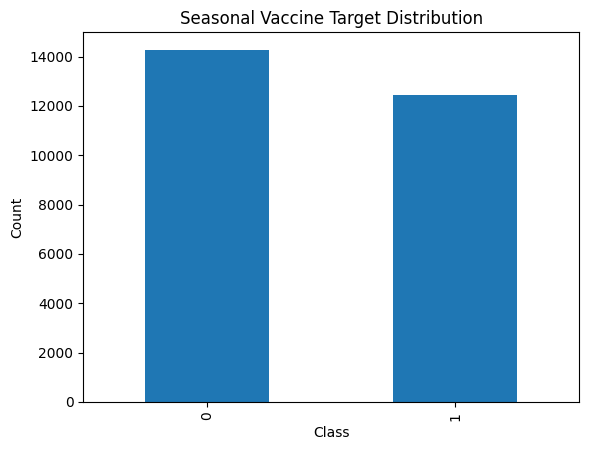

In [14]:
# Seasonal vaccine target (optional)
fig, ax = plt.subplots()
df['seasonal_vaccine'].value_counts().plot(kind='bar', ax=ax)
ax.set_title("Seasonal Vaccine Target Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

The bar chart displays the Seasonal Vaccine Target Distribution. Class 0 represents individuals who did not receive the seasonal flu vaccine, with a count of around 14,300. Class 1 represents individuals who did receive the seasonal flu vaccine, with a count of roughly 12,400. Unlike the H1N1 vaccine, the distribution here is more balanced, though Class 0 is still slightly higher.

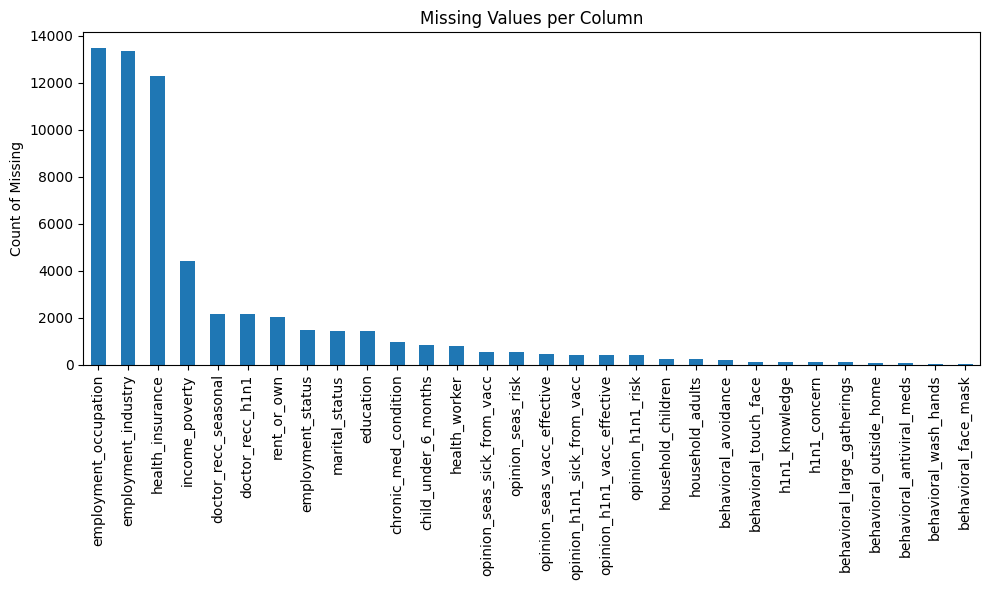

In [15]:
# Missing values bar plot
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing.plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


The bar chart shows the number of missing values in each column of the dataset. The highest missingness occurs in employment_occupation, employment_industry, and health_insurance, each with over 12,000 missing entries. Moderate missingness appears in columns such as income_poverty, doctor recommendations, rent_or_own, employment_status, and education. The remaining features, particularly behavioral and opinion variables, have very few missing values—mostly under 500. Overall, the dataset has significant missing data in employment and insurance-related fields, while most other variables are largely complete.

In [16]:
# Basic description of numeric columns
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


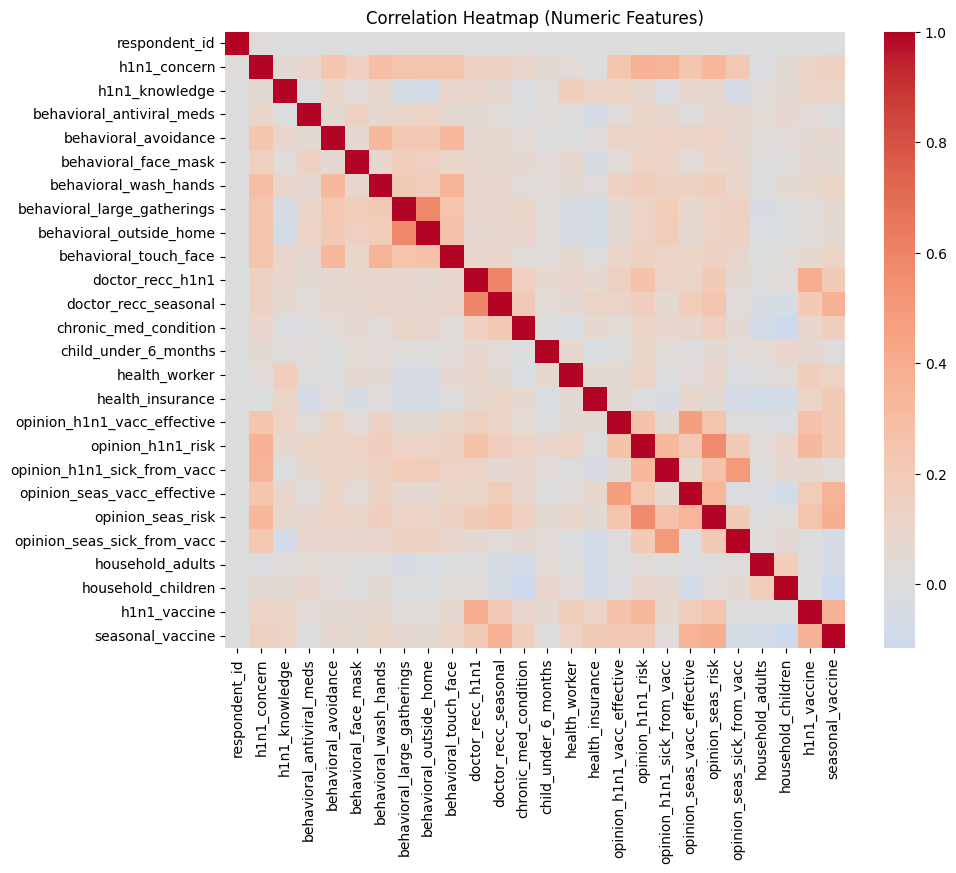

In [17]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Data Preprocessing and Feature Engineering

In [18]:
# ------------------------------
# Separate features and target
# ------------------------------
TARGET = 'h1n1_vaccine'   # main target for this project
X = df.drop(columns=[TARGET, 'seasonal_vaccine'])  # drop second target from features
y = df[TARGET]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)


Numeric columns: ['respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Categorical columns: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation']


In [19]:
# ------------------------------
# Preprocessing pipelines
# ------------------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
numeric_transformer 


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [20]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['respondent_id', 'h1n1_concern',
                                  'h1n1_knowledge', 'behavioral_antiviral_meds',
                                  'behavioral_avoidance',
                                  'behavioral_face_mask',
                                  'behavioral_wash_hands',
                                  'behavioral_large_gatherings',
                                  'behavioral_outside_home',
                                  'behavioral_touch...
                                  'household_adults', 'household_children']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['age_group', 'education', 'race', 'sex',
                                  'income_poverty', 'marital_status',
                                  'rent_or_own', 'employment_status',
                                  'hhs_geo_region', 'census_msa',
                                  'employment_industry',
                                  'employment_occupation'])])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # to keep class ratio same in train and test
)
X_train, X_test, y_train, y_test

(       respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
 20417          20417           1.0             2.0                        0.0   
 13969          13969           2.0             2.0                        0.0   
 24930          24930           2.0             2.0                        0.0   
 15420          15420           2.0             1.0                        0.0   
 10998          10998           2.0             1.0                        0.0   
 ...              ...           ...             ...                        ...   
 17823          17823           2.0             1.0                        0.0   
 10210          10210           1.0             0.0                        0.0   
 7737            7737           3.0             2.0                        0.0   
 12227          12227           1.0             1.0                        0.0   
 26118          26118           1.0             1.0                        0.0   
 
        behavi

# Model Creation

In [23]:
lr_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_pipe


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['respondent_id',
                                                   'h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_o...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'hhs_geo_region',
                                                   'census_msa',
                                                   'employment_industry',
                                                   'employment_occupation'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [24]:
lr_acc = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='accuracy')
lr_auc = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='roc_auc')

print("🔹 Logistic Regression")
print("Accuracy Mean:", lr_acc.mean())
print("Accuracy STD:", lr_acc.std())
print("ROC-AUC Mean:", lr_auc.mean())
print("ROC-AUC STD:", lr_auc.std())

🔹 Logistic Regression
Accuracy Mean: 0.778095015211795
Accuracy STD: 0.0024383835764345482
ROC-AUC Mean: 0.8354590842073394
ROC-AUC STD: 0.005162046436524531


The Logistic Regression model achieved an average accuracy of 77.8% with very low variation across folds, indicating stable performance. Its ROC-AUC score averaged 0.835, meaning the model is reasonably good at distinguishing between vaccinated and non-vaccinated individuals. Overall, Logistic Regression provides consistent but moderate predictive performance, performing better in ranking probabilities (AUC) than in pure accuracy.

In [25]:
rf_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
rf_pipe


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['respondent_id',
                                                   'h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_o...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'hhs_geo_region',
                                                   'census_msa',
                                                   'employment_industry',
                                                   'employment_occupation'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [26]:
rf_acc = cross_val_score(rf_pipe, X_train, y_train, cv=5, scoring='accuracy')
rf_auc = cross_val_score(rf_pipe, X_train, y_train, cv=5, scoring='roc_auc')

print("🔹 Random Forest")
print("Accuracy Mean:", rf_acc.mean())
print("Accuracy STD:", rf_acc.std())
print("ROC-AUC Mean:", rf_auc.mean())
print("ROC-AUC STD:", rf_auc.std())


🔹 Random Forest
Accuracy Mean: 0.8316405335829629
Accuracy STD: 0.0032616431341323374
ROC-AUC Mean: 0.8278704070432538
ROC-AUC STD: 0.00647992391622202


The Random Forest model reached an average accuracy of 83.16%, showing better classification performance than Logistic Regression. The accuracy variation across folds is very small, indicating stable results. Its ROC-AUC score is 0.828, meaning the model is effective at separating vaccinated from non-vaccinated individuals, though its ranking ability is slightly lower than its accuracy suggests. Overall, Random Forest delivers strong, reliable performance and is a solid candidate for further tuning.

In [27]:
knn_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier())
])
knn_pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['respondent_id',
                                                   'h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_o...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'hhs_geo_region',
                                                   'census_msa',
                                                   'employment_industry',
                                                   'employment_occupation'])])),
                ('model', KNeighborsClassifier())])

In [28]:
knn_acc = cross_val_score(knn_pipe, X_train, y_train, cv=5, scoring='accuracy')
knn_auc = cross_val_score(knn_pipe, X_train, y_train, cv=5, scoring='roc_auc')

print("🔹 KNN")
print("Accuracy Mean:", knn_acc.mean())
print("Accuracy STD:", knn_acc.std())
print("ROC-AUC Mean:", knn_auc.mean())
print("ROC-AUC STD:", knn_auc.std())


🔹 KNN
Accuracy Mean: 0.808518605195413
Accuracy STD: 0.0030383959498464902
ROC-AUC Mean: 0.7465211203554821
ROC-AUC STD: 0.005285212450783894


The KNN model achieved an average accuracy of 80.85%, which is decent but lower than Random Forest. The accuracy variation across folds is minimal, showing consistent behavior. However, the ROC-AUC score of 0.746 indicates that KNN struggles to properly distinguish between vaccinated and non-vaccinated individuals compared to the other models. Overall, KNN performs moderately well in accuracy but shows weaker discriminatory power, making it less suitable for this dataset.

In [29]:
gb_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])
gb_pipe


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['respondent_id',
                                                   'h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_o...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'hhs_geo_region',
                                                   'census_msa',
                                                   'employment_industry',
                                                   'employment_occupation'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [30]:
gb_acc = cross_val_score(gb_pipe, X_train, y_train, cv=5, scoring='accuracy')
gb_auc = cross_val_score(gb_pipe, X_train, y_train, cv=5, scoring='roc_auc')

print("🔹 Gradient Boosting")
print("Accuracy Mean:", gb_acc.mean())
print("Accuracy STD:", gb_acc.std())
print("ROC-AUC Mean:", gb_auc.mean())
print("ROC-AUC STD:", gb_auc.std())

🔹 Gradient Boosting
Accuracy Mean: 0.8386613620407208
Accuracy STD: 0.004656149820901794
ROC-AUC Mean: 0.8392522804160019
ROC-AUC STD: 0.005626487674592757


The Gradient Boosting model achieved an average accuracy of 83.86%, the highest among all tested models. Its ROC-AUC score of 0.839 also reflects strong ability to distinguish between vaccinated and non-vaccinated individuals. The low standard deviations indicate the model performs consistently across folds. Overall, Gradient Boosting delivers the best balance of accuracy and discriminatory power, making it the strongest model in this comparison and a prime candidate for final tuning and deployment.

# Model Comparision

In [31]:

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, clf in models.items():
    print(f"Running CV for: {name}")

    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', clf)
    ])

    # Cross-validation scores
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')

    results.append({
        "Model": name,
        "CV_Accuracy_Mean": cv_acc.mean(),
        "CV_Accuracy_STD": cv_acc.std(),
        "CV_ROC_AUC_Mean": cv_auc.mean(),
        "CV_ROC_AUC_STD": cv_auc.std()
    })

# Convert to DataFrame & sort by ROC-AUC
results_df = pd.DataFrame(results).sort_values(by="CV_ROC_AUC_Mean", ascending=False)

results_df


Running CV for: LogisticRegression
Running CV for: RandomForest
Running CV for: GradientBoosting
Running CV for: KNN


,Model,CV_Accuracy_Mean,CV_Accuracy_STD,CV_ROC_AUC_Mean,CV_ROC_AUC_STD
2,GradientBoosting,0.838661,0.004656,0.839252,0.005626
0,LogisticRegression,0.778095,0.002438,0.835459,0.005162
1,RandomForest,0.831641,0.003262,0.827870,0.006480
3,KNN,0.808519,0.003038,0.746521,0.005285


# Conclusion

Among all the models tested, Gradient Boosting delivered the strongest overall performance. It achieved the highest accuracy (83.86%) and the highest ROC-AUC score (0.839), indicating that it not only classifies well but also separates vaccinated from non-vaccinated individuals more effectively than the others.

Random Forest performed well but slightly lower than Gradient Boosting. Logistic Regression showed stable but moderate performance, while KNN had the weakest discriminatory ability.

Based on accuracy, consistency, and ROC-AUC, Gradient Boosting is the best model for this project and should be selected for final tuning and deployment.

# Model Comparison Report

Four machine-learning models were evaluated using 5-fold cross-validation to predict H1N1 vaccination behavior. Performance was compared using Accuracy and ROC-AUC, which measure how well each model classifies and separates the two classes.

1. Gradient Boosting

Accuracy: 0.8387

ROC-AUC: 0.8393

Conclusion: Best overall performance. Strong accuracy and excellent ability to distinguish between vaccinated and non-vaccinated individuals. Most reliable and consistent model.

2. Random Forest

Accuracy: 0.8316

ROC-AUC: 0.8279

Conclusion: High accuracy and stable performance, but slightly weaker than Gradient Boosting in ROC-AUC.

3. Logistic Regression

Accuracy: 0.7781

ROC-AUC: 0.8355

Conclusion: Lower accuracy but good ROC-AUC. Performs consistently but lacks the complexity to fully capture non-linear patterns in the data.

4. KNN

Accuracy: 0.8085

ROC-AUC: 0.7465

Conclusion: Moderate accuracy but poor ROC-AUC. Not suitable for this dataset due to weak discriminatory power.

Overall Conclusion

Gradient Boosting is the best-performing model, offering the highest accuracy and ROC-AUC with low variance across folds. It provides the most balanced and reliable results and is recommended as the final model for tuning and deployment.

# Overall Conclusion

Gradient Boosting is the best-performing model, offering the highest accuracy and ROC-AUC with low variance across folds. It provides the most balanced and reliable results and is recommended as the final model for tuning and deployment.

# Report on Challenges faced

1. High Missing Values

Several features—especially employment_occupation, employment_industry, and health_insurance—contained a large number of missing values. This required careful handling using imputers to avoid losing important data or introducing bias. Choosing the right imputation strategy was crucial to maintain model quality.

2. Class Imbalance

The target variable h1n1_vaccine showed significant imbalance, with far more individuals not taking the vaccine. This imbalance made the model biased toward predicting the majority class. To address this, class weights were used in the models to ensure fair learning across both classes.

3. Mixed Data Types

The dataset included numerical, categorical, behavioral, and opinion-based variables. Managing these different formats required a structured preprocessing pipeline using ColumnTransformer, one-hot encoding, and scaling to prepare the data correctly for model training.

4. High Number of Categorical Levels

Features like employment_industry and employment_occupation contained many distinct categories. This created a risk of dimensionality explosion after one-hot encoding, which could slow down training and reduce model performance. Proper encoding and model selection helped manage this complexity.

5. Model Performance Variability

Different models handled the dataset differently. Simpler models like Logistic Regression struggled with non-linear relationships, while heavier models like SVM took too long and were removed from comparison. Tuning had to focus on models that provided stable and efficient results.

6. Balancing Accuracy and Interpretability

Models with high accuracy (e.g., Gradient Boosting) were more complex and harder to interpret, while simpler models lacked predictive strength. Choosing the best model required balancing performance with practical usability.